In [8]:
# Regular EDA and plotting libraries
import numpy as np  #tableaux et matrices
import pandas as pd # Permet de manipuler et d'analyser des données sous forme de dataframes, ce qui est similaire à des tableaux Excel
import matplotlib.pyplot as plt  #Permet de créer des visualisations de données, comme des graphiques et des diagrammes.
import seaborn as sns #  Permet de créer des visualisations de données plus complexes et plus attrayantes que celles fournies par matplotlib.

# We want our plots to appear in the notebook
# Afin de visualiser les graphiques dans le notebook
%matplotlib inline 


# Importation des métriques
from sklearn.metrics import accuracy_score

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score #utilisés pour diviser les données en ensembles d'entraînement et de test, et pour évaluer les modèles à l'aide de la validation croisée.
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV #pour ajuster les hyperparamètres des modèles.
from sklearn.metrics import confusion_matrix, classification_report # pour évaluer les performances des modèles de classification.
from sklearn.metrics import precision_score, recall_score, f1_score #pour évaluer les performances des modèles de classification.
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+( utilisez une version antérieure de Scikit-Learn) #utilisé pour afficher la courbe ROC des modèles de classification.

# Print last updated
import time
print(f"Last updated: {time.asctime()}")

Last updated: Sat Apr 11 10:17:08 2026


In [9]:
df = pd.read_csv("heart_disease_dataset.csv") # 'DataFrame' shortened to 'df'  # charger le jeu de données 
df.shape # (rows, columns)  # afficher sa taille

(1000, 16)

In [10]:
# And the top 10
df.head(10) #Cela affichera les 10 premières lignes du DataFrame 

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0
5,77,Male,309,110,73,Never,NaN,0,No,Yes,Yes,4,122,Yes,Asymptomatic,1
6,64,Female,211,105,86,Former,Heavy,8,Yes,Yes,Yes,2,120,No,Typical Angina,1
7,60,Female,208,148,83,Never,Moderate,4,No,Yes,Yes,2,113,Yes,Asymptomatic,1
8,37,Female,317,137,66,Current,Heavy,3,No,Yes,Yes,5,114,No,Non-anginal Pain,0
9,63,Male,204,141,68,Former,Heavy,8,No,Yes,No,3,107,No,Asymptomatic,1


In [11]:
#changer noms des attributs

df = df.rename(columns={
    "Age": "age",
    "Gender": "gender",
    "Cholesterol": "chol",
    "Blood Pressure": "bp",
    "Heart Rate": "hr",
    "Smoking": "smoke",
    "Alcohol Intake": "alcohol",
    "Exercise Hours": "exercise",
    "Family History": "family_hist",
    "Diabetes": "diabetes",
    "Obesity": "obesity",
    "Stress Level": "stress",
    "Blood Sugar": "sugar",
    "Exercise Induced Angina": "angina",
    "Chest Pain Type": "cp",
    "Heart Disease": "target"
})

In [13]:
df = df.replace({
    # Gender
    "gender": {"Male": 1, "Female": 0},
    
    # Yes / No
    "family_hist": {"Yes": 1, "No": 0},
    "diabetes": {"Yes": 1, "No": 0},
    "obesity": {"Yes": 1, "No": 0},
    "angina": {"Yes": 1, "No": 0},
    
    # Chest Pain Type
    "cp": {
        "Typical Angina": 0,
        "Atypical Angina": 1,
        "Non-anginal Pain": 2,
        "Asymptomatic": 3
    }
})

# Smoking (3 catégories)
df["smoke"] = df["smoke"].replace({
    "Never": 0,
    "Former": 1,
    "Current": 2
})

# Alcohol (3 catégories + NaN)
df["alcohol"] = df["alcohol"].replace({
    "Moderate": 1,
    "Heavy": 2
})

df["alcohol"] = df["alcohol"].fillna(0)

C:\Users\mhbm\AppData\Local\Temp\ipykernel_1808\4036420666.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({
C:\Users\mhbm\AppData\Local\Temp\ipykernel_1808\4036420666.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["smoke"] = df["smoke"].replace({
C:\Users\mhbm\AppData\Local\Temp\ipykernel_1808\4036420666.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in

In [14]:
df.head(10)

,age,gender,chol,bp,hr,smoke,alcohol,exercise,family_hist,diabetes,obesity,stress,sugar,angina,cp,target
0,75,0,228,119,66,2,2.0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,2,0.0,5,0,0,0,9,70,1,0,0
2,53,1,234,91,67,0,2.0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,2,0.0,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,0,0.0,6,0,1,0,2,183,1,3,0
5,77,1,309,110,73,0,0.0,0,0,1,1,4,122,1,3,1
6,64,0,211,105,86,1,2.0,8,1,1,1,2,120,0,0,1
7,60,0,208,148,83,0,1.0,4,0,1,1,2,113,1,3,1
8,37,0,317,137,66,2,2.0,3,0,1,1,5,114,0,2,0
9,63,1,204,141,68,1,2.0,8,0,1,0,3,107,0,3,1


In [15]:
df.dtypes  # Donne le type de données de chaque colonne

age              int64
gender           int64
chol             int64
bp               int64
hr               int64
smoke            int64
alcohol        float64
exercise         int64
family_hist      int64
diabetes         int64
obesity          int64
stress           int64
sugar            int64
angina           int64
cp               int64
target           int64
dtype: object

In [17]:
#Afficher la somme des valeurs manquantes

print("Nombre de valeur manquantes:",df.isnull().sum().sum())

Nombre de valeur manquantes: 0


In [18]:
# Vérifier les doublons
duplicate_rows = df[df.duplicated()]
print("Nombre de lignes dupliquées:", duplicate_rows.shape[0])

Nombre de lignes dupliquées: 0


In [19]:
# Vérification des outliers
print("\nVérification des outliers :")
for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)].index
    print(f"{column}: {len(outliers)}")


Vérification des outliers :
age: 0
gender: 0
chol: 0
bp: 0
hr: 0
smoke: 0
alcohol: 0
exercise: 0
family_hist: 0
diabetes: 0
obesity: 0
stress: 0
sugar: 0
angina: 0
cp: 0
target: 0


In [20]:
from sklearn.preprocessing import MinMaxScaler

# Initialiser le scaler
scaler = MinMaxScaler()

# Normaliser les colonnes numériques
df_normalized = pd.DataFrame(scaler.fit_transform(df.select_dtypes(include=[float, int])), columns=df.select_dtypes(include=[float, int]).columns)

# Si vous voulez conserver les colonnes non numériques
df_non_numeric = df.select_dtypes(exclude=[float, int])
df_normalized = pd.concat([df_normalized, df_non_numeric], axis=1)

print("Dataset normalisé avec Min-Max Scaling:")
print(df_normalized.head())


Dataset normalisé avec Min-Max Scaling:
        age  gender      chol        bp        hr  smoke  alcohol  exercise  \
0  0.925926     0.0  0.391960  0.325843  0.153846    1.0      1.0  0.111111   
1  0.425926     1.0  0.271357  0.842697  0.051282    1.0      0.0  0.555556   
2  0.518519     1.0  0.422111  0.011236  0.179487    0.0      1.0  0.333333   
3  0.814815     0.0  0.211055  0.000000  0.307692    1.0      0.0  0.444444   
4  0.685185     0.0  0.110553  0.820225  0.846154    0.0      0.0  0.666667   

   family_hist  diabetes  obesity    stress     sugar  angina        cp  \
0          0.0       0.0      1.0  0.777778  0.379845     1.0  0.333333   
1          0.0       0.0      0.0  0.888889  0.000000     1.0  0.000000   
2          1.0       0.0      1.0  0.444444  0.976744     1.0  0.333333   
3          0.0       1.0      0.0  0.666667  0.286822     1.0  0.666667   
4          0.0       1.0      0.0  0.111111  0.875969     1.0  1.000000   

   target  
0     1.0  
1     0.0 

In [21]:
#Afficher la somme des valeurs manquantes
df.isnull().sum()

age            0
gender         0
chol           0
bp             0
hr             0
smoke          0
alcohol        0
exercise       0
family_hist    0
diabetes       0
obesity        0
stress         0
sugar          0
angina         0
cp             0
target         0
dtype: int64

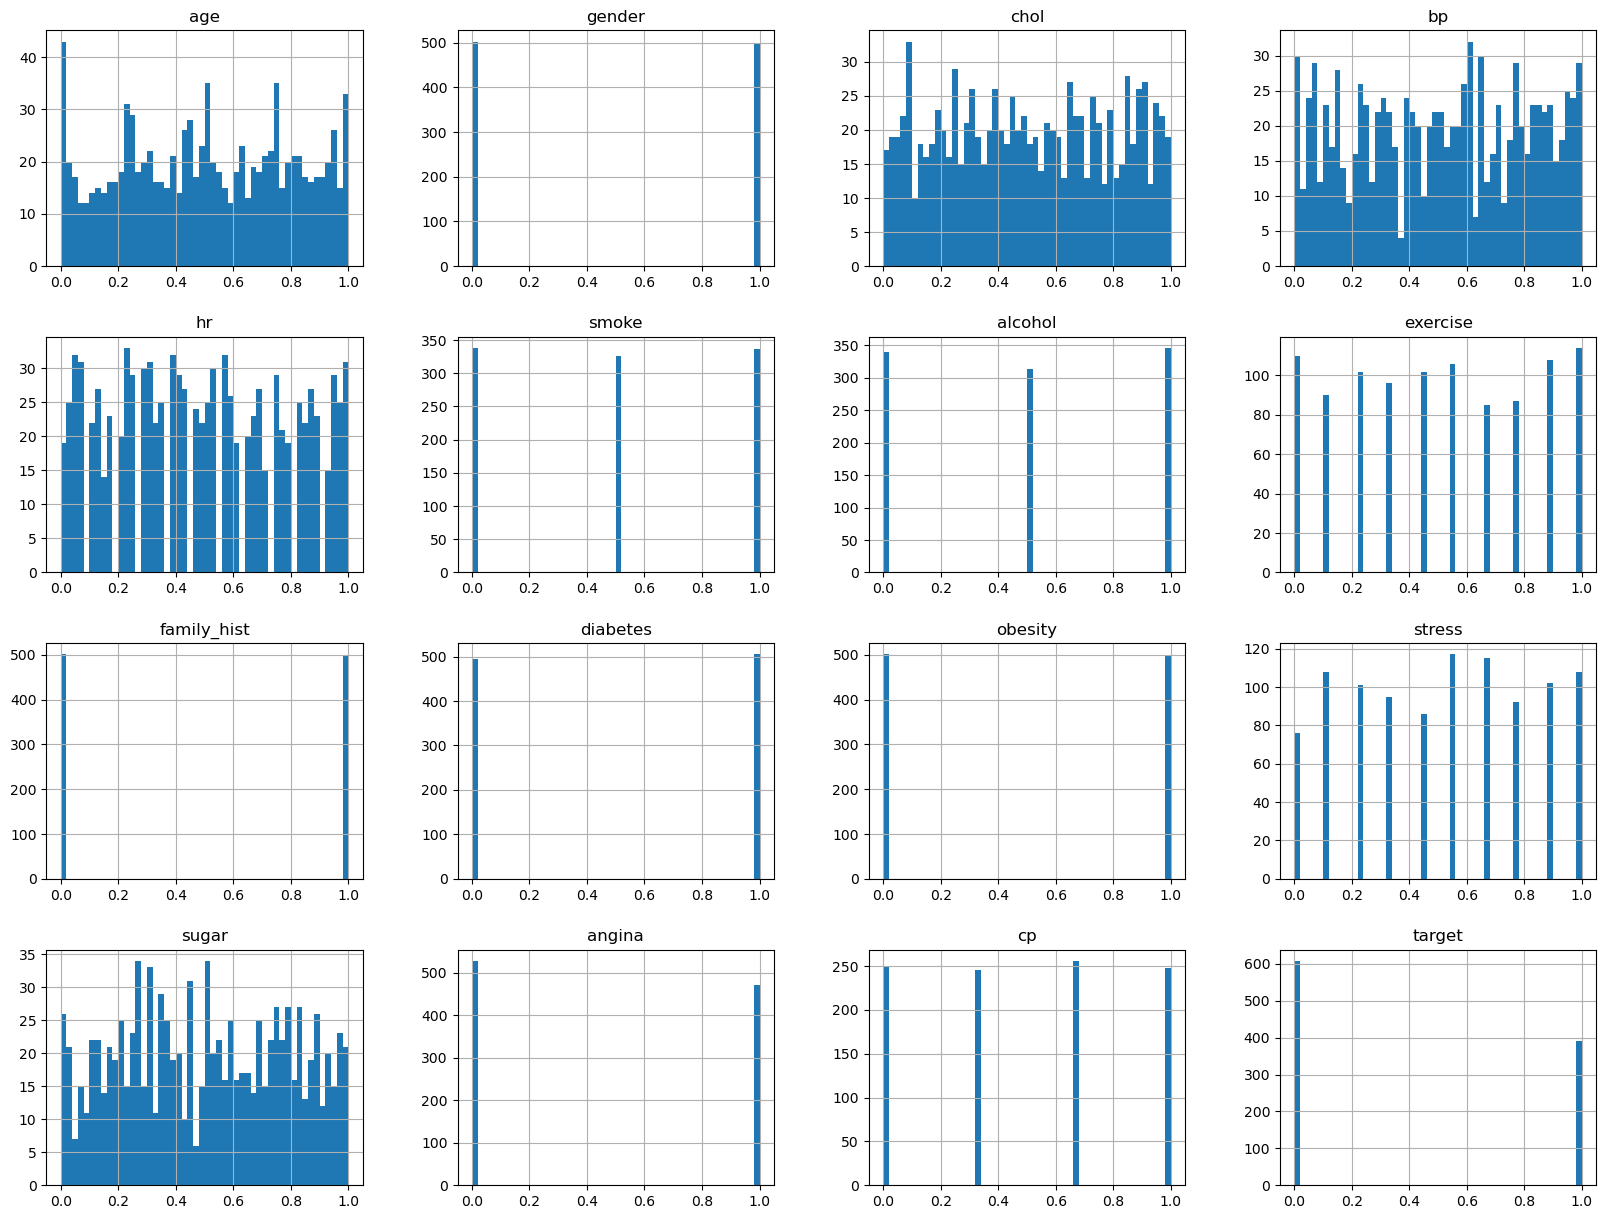

In [22]:
import matplotlib.pyplot as plt

# Afficher l'histogramme des colonnes normalisées
df_normalized.hist(bins=50, figsize=(20, 15))
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialiser le scaler
scaler = StandardScaler()

# Normaliser les colonnes numériques
df_standardized = pd.DataFrame(scaler.fit_transform(df.select_dtypes(include=[float, int])), columns=df.select_dtypes(include=[float, int]).columns)

# Si vous voulez conserver les colonnes non numériques
df_non_numeric = df.select_dtypes(exclude=[float, int])
df_standardized = pd.concat([df_standardized, df_non_numeric], axis=1)

print("Dataset standardisé avec Z-score Scaling:")
print(df_standardized.head())


Dataset standardisé avec Z-score Scaling:
        age    gender      chol        bp        hr     smoke   alcohol  \
0  1.444534 -0.994018 -0.379005 -0.617287 -1.150139  1.220504  1.200151   
1 -0.273104  1.006018 -0.793616  1.126782 -1.498561  1.220504 -1.214639   
2  0.044977  1.006018 -0.275353 -1.678894 -1.063034 -1.215631  1.200151   
3  1.062836 -0.994018 -1.000921 -1.716808 -0.627507  1.220504 -1.214639   
4  0.617523 -0.994018 -1.346429  1.050953  1.201706 -1.215631 -1.214639   

   exercise  family_hist  diabetes   obesity    stress     sugar   angina  \
0 -1.203298    -0.998002 -1.010051  1.002002  0.831917 -0.434581  1.05766   
1  0.160599    -0.998002 -1.010051 -0.998002  1.185323 -1.770413  1.05766   
2 -0.521350     1.002002 -1.010051  1.002002 -0.228300  1.664583  1.05766   
3 -0.180375    -0.998002  0.990050 -0.998002  0.478511 -0.761724  1.05766   
4  0.501573    -0.998002  0.990050 -0.998002 -1.288517  1.310178  1.05766   

         cp    target  
0 -0.449723  1.24540

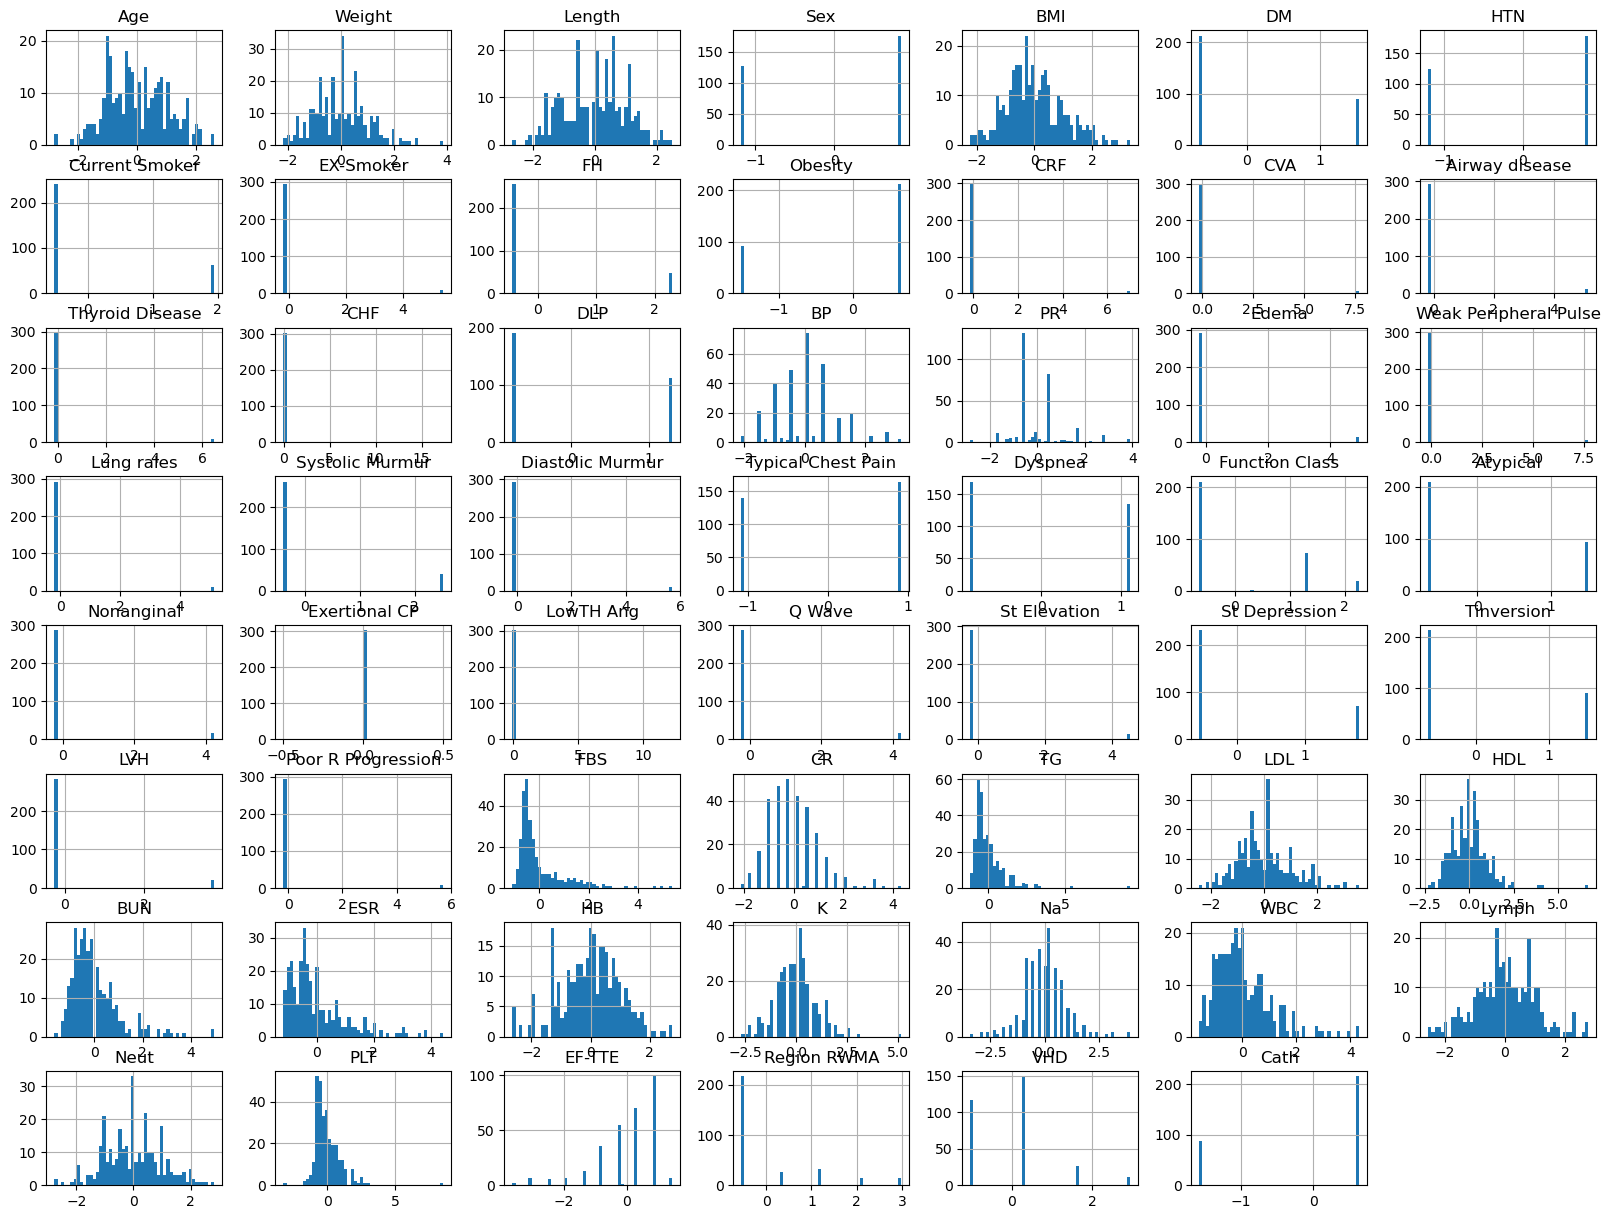

In [19]:
# Afficher l'histogramme des colonnes standardisées
df_standardized.hist(bins=50, figsize=(20, 15))
plt.show()


In [24]:
# Enregistrer le DataFrame modifié dans un nouveau fichier CSV
df.to_csv("heart_disease_dataset1.csv", index=False)